In [6]:
# === CELL 1: Load & parse Dyslexia data ===
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.ensemble import RandomForestClassifier

base = Path("..") / "data" / "raw" / "Predicting Risk of Dyslexia - PLOS ONE"

# IMPORTANT: semicolon-separated file
dys = pd.read_csv(base / "Dyt-desktop.csv", sep=";")

print("Parsed dyslexia shape:", dys.shape)
print("Columns:", dys.columns.tolist()[:10])
dys.head()


Parsed dyslexia shape: (3644, 197)
Columns: ['Gender', 'Nativelang', 'Otherlang', 'Age', 'Clicks1', 'Hits1', 'Misses1', 'Score1', 'Accuracy1', 'Missrate1']


,Gender,Nativelang,Otherlang,Age,Clicks1,Hits1,Misses1,Score1,Accuracy1,Missrate1,...,Score31,Accuracy31,Missrate31,Clicks32,Hits32,Misses32,Score32,Accuracy32,Missrate32,Dyslexia
0,Male,No,Yes,7,10,10,0,10,1.0,0.0,...,0,0.000000,0.00,17,2,0,2,0.117647,0.000000,No
1,Female,Yes,Yes,13,12,12,0,12,1.0,0.0,...,4,0.114286,0.00,26,2,2,2,0.076923,0.076923,Yes
2,Female,No,Yes,7,6,6,0,6,1.0,0.0,...,4,0.114286,0.00,26,1,3,1,0.038462,0.115385,No
3,Female,No,Yes,7,0,0,0,0,0.0,0.0,...,0,0.000000,0.00,1,0,0,0,0.000000,0.000000,No
4,Female,No,Yes,8,4,4,0,4,1.0,0.0,...,1,25.000000,0.05,26,2,2,2,0.076923,0.076923,No


In [7]:
# === CELL 2: Preprocess ===

target_col = "Dyslexia"

X = dys.drop(columns=[target_col])
y = dys[target_col].map({'Yes': 1, 'No': 0})

# Keep numeric features only
X = X.select_dtypes(include=[np.number])
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (2733, 193) Test: (911, 193)


In [8]:
# === CELL 3: Train RandomForest ===
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probs)

print("✅ Dyslexia Risk AUC:", round(auc, 3))
print(classification_report(y_test, model.predict(X_test)))


✅ Dyslexia Risk AUC: 0.821
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       813
           1       1.00      0.02      0.04        98

    accuracy                           0.89       911
   macro avg       0.95      0.51      0.49       911
weighted avg       0.91      0.89      0.85       911



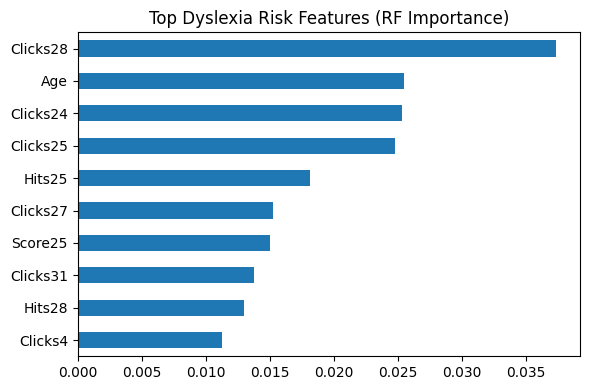

In [9]:
# === CELL 4: Feature importance (fallback XAI) ===
importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(10).plot(kind="barh", figsize=(6,4))
plt.title("Top Dyslexia Risk Features (RF Importance)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../results/figures/dyslexia_feature_importance.png")
plt.show()


In [10]:
# === CELL 5: Save model ===
import joblib

joblib.dump(model, "../models/risk_rf.pkl")
print("✅ SAVED risk_rf.pkl")

sample = X_test.iloc[:1]
risk = model.predict_proba(sample)[0, 1]
print(f"Sample risk score: {risk:.3f}")

print("✅ DYSLEXIA MODEL READY")


✅ SAVED risk_rf.pkl
Sample risk score: 0.017
✅ DYSLEXIA MODEL READY
